<a href="https://colab.research.google.com/github/SergeiVKalinin/Probabilistic-Unmixing-0/blob/main/notebooks/07_Level_2_Functional_Modes_and_Prior_Geometry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 07 — Level 2: Functional Modes and Prior Geometry

Level 2 compresses an ensemble of complete spectra into a low-dimensional functional representation.

The current implementation works in **log-spectrum space**:

1. normalize every library spectrum;
2. add a small positive floor and take the logarithm;
3. center the log spectra;
4. perform PCA/SVD;
5. retain a small set of scaled functional modes;
6. assign standard-normal coefficients to those modes;
7. exponentiate and renormalize to obtain positive, unit-area physical spectra.

A PCA mode is therefore **not itself a spectrum**. It is a direction in latent log-function space. This notebook makes the distinction visible.

In [1]:
!pip install -q --force-reinstall --no-deps git+https://github.com/SergeiVKalinin/Probabilistic-Unmixing-0.git

import numpy as np
import matplotlib.pyplot as plt
import probunmix as pu

print("probunmix version:", pu.__version__)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
probunmix version: 0.1.0


## Build the same functional representation used by Level 2

This is an advanced diagnostic notebook, so it imports a few internal Level 2 helpers. The public inference API remains `pu.fit(data, level=2)`.

In [2]:
from probunmix.level2 import (
    _build_representations,
    _quadrature_weights,
    _spectrum_from_coefficients,
)

data = pu.generate_example(
    n_locations=40,
    n_channels=140,
    n_library=300,
    spectral_uncertainty=[1.0, 1.5, 1.0, 1.0],
    seed=42,
)

representations, normalized_library = _build_representations(
    data.E,
    data.S_library,
    variance_threshold=0.995,
    min_rank=4,
    max_rank=12,
)

for k, rep in enumerate(representations):
    print(
        f"Component {k+1}: retained rank={rep['rank']}, "
        f"required rank={rep['required_rank']}, "
        f"explained variance={rep['explained_variance']:.5f}"
    )

Component 1: retained rank=12, required rank=12, explained variance=0.99547
Component 2: retained rank=12, required rank=19, explained variance=0.98068
Component 3: retained rank=10, required rank=10, explained variance=0.99616
Component 4: retained rank=10, required rank=10, explained variance=0.99536


## Inspect the leading latent modes

The vertical axis below is a log-function perturbation. Positive and negative values are expected. These basis functions should not be interpreted as physical nonnegative spectra.

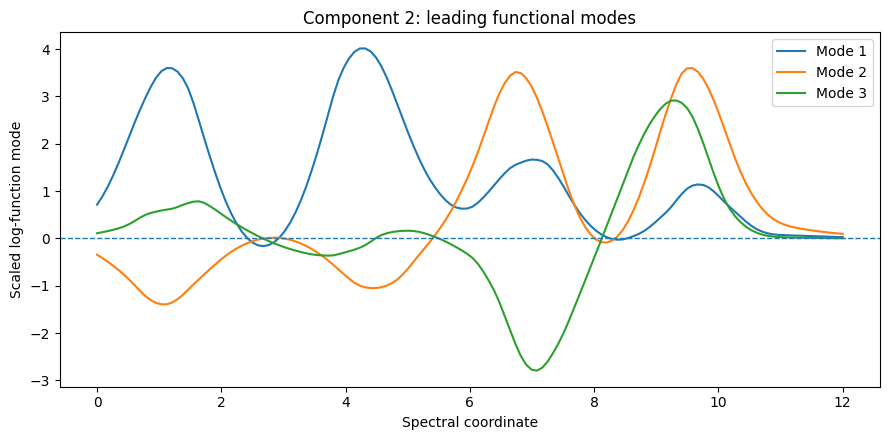

In [3]:
component = 1
rep = representations[component]

n_modes_to_show = min(3, rep["rank"])

fig, ax = plt.subplots(figsize=(9, 4.5))

for j in range(n_modes_to_show):
    ax.plot(data.E, rep["basis"][:, j], label=f"Mode {j+1}")

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Spectral coordinate")
ax.set_ylabel("Scaled log-function mode")
ax.set_title(f"Component {component+1}: leading functional modes")
ax.legend()
fig.tight_layout();

## What does one mode do to the physical spectrum?

The physical map is nonlinear because the latent log function is exponentiated and renormalized.

Here we set all coefficients to zero except the first mode, which is assigned $-1$, $0$, or $+1$ standard deviations.

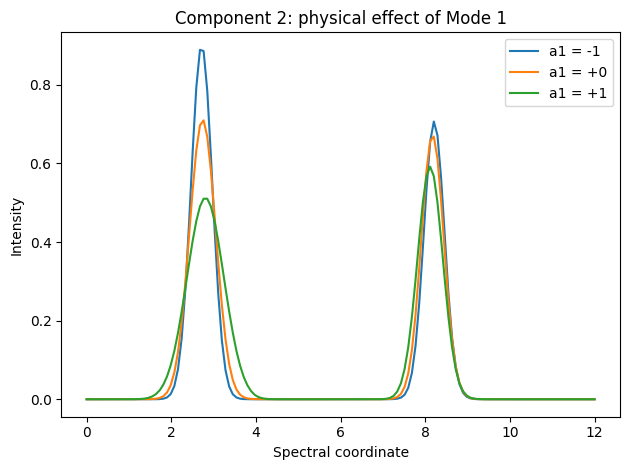

In [4]:
q = _quadrature_weights(data.E)

for amplitude in [-1.0, 0.0, 1.0]:
    a = np.zeros(rep["rank"])
    a[0] = amplitude

    spectrum = _spectrum_from_coefficients(
        rep["mean"],
        rep["basis"],
        a,
        q,
    )

    plt.plot(data.E, spectrum, label=f"a1 = {amplitude:+.0f}")

plt.xlabel("Spectral coordinate")
plt.ylabel("Intensity")
plt.title(f"Component {component+1}: physical effect of Mode 1")
plt.legend()
plt.tight_layout();

## Sample the induced functional prior

The Gaussian distribution lives in coefficient space. After exponentiation and area normalization it becomes a nonlinear distribution over physical spectra.

This induced prior is not identical to the original empirical library, even though the library is what defined the latent representation.

In [5]:
rng = np.random.default_rng(123)
n_draws = 2000

coefficients = rng.normal(
    size=(n_draws, rep["rank"])
)

prior_draws = np.array([
    _spectrum_from_coefficients(
        rep["mean"],
        rep["basis"],
        a,
        q,
    )
    for a in coefficients
])

print("Prior draw shape:", prior_draws.shape)
print(
    "Maximum area error:",
    np.max(np.abs(np.trapz(prior_draws, data.E, axis=1) - 1.0))
)

Prior draw shape: (2000, 140)
Maximum area error: 6.661338147750939e-16


/tmp/ipykernel_510/2162566993.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.max(np.abs(np.trapz(prior_draws, data.E, axis=1) - 1.0))


## Library versus induced prior

The means and uncertainty bands need not coincide exactly because low-rank Gaussianization and the nonlinear physical transformation modify the distribution.

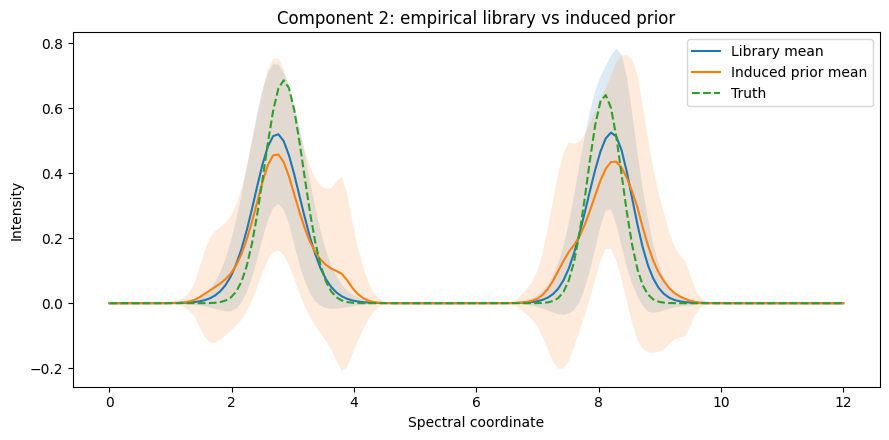

In [6]:
library = normalized_library[component]

fig, ax = plt.subplots(figsize=(9, 4.5))

for ensemble, label in [
    (library, "Library"),
    (prior_draws, "Induced prior"),
]:
    mean = ensemble.mean(axis=0)
    sd = ensemble.std(axis=0, ddof=1)
    ax.plot(data.E, mean, label=f"{label} mean")
    ax.fill_between(data.E, mean - sd, mean + sd, alpha=0.15)

ax.plot(data.E, data.S_true[component], "--", label="Truth")
ax.set_xlabel("Spectral coordinate")
ax.set_ylabel("Intensity")
ax.set_title(f"Component {component+1}: empirical library vs induced prior")
ax.legend()
fig.tight_layout();

## The arithmetic mean is not the zero-coefficient spectrum

Exponentiation and normalization are nonlinear operations. Therefore the spectrum obtained by setting all latent coefficients to zero generally differs from the arithmetic mean of physical prior draws.

RMS difference between zero-coefficient spectrum and prior mean: 0.0740509438216305


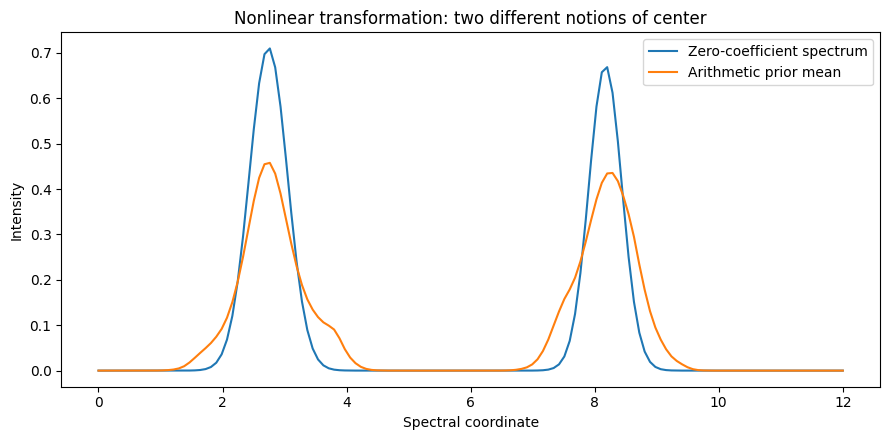

In [7]:
zero_spectrum = _spectrum_from_coefficients(
    rep["mean"],
    rep["basis"],
    np.zeros(rep["rank"]),
    q,
)

prior_mean = prior_draws.mean(axis=0)

print(
    "RMS difference between zero-coefficient spectrum and prior mean:",
    np.sqrt(np.mean((zero_spectrum - prior_mean)**2))
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(data.E, zero_spectrum, label="Zero-coefficient spectrum")
ax.plot(data.E, prior_mean, label="Arithmetic prior mean")
ax.set_xlabel("Spectral coordinate")
ax.set_ylabel("Intensity")
ax.set_title("Nonlinear transformation: two different notions of center")
ax.legend()
fig.tight_layout();

## Compare covariance of the library and induced prior

A low-dimensional latent Gaussian can still induce rich covariance in physical intensity space.

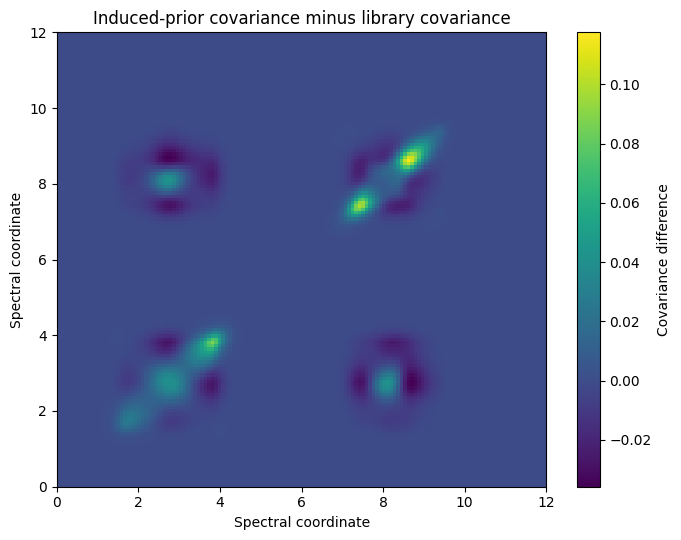

In [8]:
cov_library = np.cov(library, rowvar=False, ddof=1)
cov_prior = np.cov(prior_draws, rowvar=False, ddof=1)

fig, ax = plt.subplots(figsize=(7, 5.5))
image = ax.imshow(
    cov_prior - cov_library,
    origin="lower",
    aspect="auto",
    extent=[data.E[0], data.E[-1], data.E[0], data.E[-1]],
)
ax.set_xlabel("Spectral coordinate")
ax.set_ylabel("Spectral coordinate")
ax.set_title("Induced-prior covariance minus library covariance")
fig.colorbar(image, ax=ax, label="Covariance difference")
fig.tight_layout();

## Takeaway

Level 2 contains three distinct objects:

1. the empirical spectral library;
2. the reduced Gaussian distribution in latent log-function coordinates;
3. the induced nonlinear distribution of positive, normalized physical spectra.

Keeping these objects conceptually separate is essential for interpreting covariance, prior width, rank truncation, and posterior uncertainty.